# Preview: Dataset507_ARCADE_refinement

Built by `prepare_arcade_507_refinement.py` -- see
`README_507_refinement.md` for the full recipe. Three patch categories per
case, sourced from `Dataset501_ARCADE` + `nnUNetTrainerENetOriginal`'s own
predictions:

- **discont** -- centered on real FN discontinuities (GT vessel the model
  missed) -- ENetOriginal's actual observed failures.
- **normal** -- GT vessel patches where the prediction already matches well
  (FN fraction <= 10%).
- **empty_fp** -- GT-empty or FP-dominated random patches.

Each case has **two input channels** (`_0000` = raw grayscale, `_0001` =
ENetOriginal's predicted mask) plus a GT label -- built for the *planned*
two-channel refinement network (`analysis/507_refinement_net_plan.md`).
`train_small_enet_507.job` is a baseline that only uses channel 0.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "dataset-prep" else Path.cwd()
ROOT = REPO_ROOT / "data" / "nnUNet_raw" / "Dataset507_ARCADE_refinement"
IMAGES_TR, LABELS_TR = ROOT / "imagesTr", ROOT / "labelsTr"
IMAGES_TS, LABELS_TS = ROOT / "imagesTs", ROOT / "labelsTs"

rng = random.Random(0)

## Dataset summary + category balance

In [2]:
dataset_json = json.loads((ROOT / "dataset.json").read_text())
splits = json.loads((ROOT / "splits_final.json").read_text())
print(json.dumps(dataset_json, indent=2))

train_cases, val_cases = splits[0]["train"], splits[0]["val"]
test_cases = sorted(p.stem for p in LABELS_TS.glob("*.png")) if LABELS_TS.exists() else []
print(f"\ntrain={len(train_cases)} val={len(val_cases)} test={len(test_cases)}")
print(f"train/val overlap: {len(set(train_cases) & set(val_cases))} (should be 0)")


def category_of(case_id: str) -> str:
    # "{source_stem}_{category}_{idx:03d}" -- category is always the second-to-last underscore segment
    return case_id.rsplit("_", 2)[1]


for split_name, cases in [("train", train_cases), ("val", val_cases), ("test", test_cases)]:
    if not cases:
        continue
    counts = {}
    for c in cases:
        cat = category_of(c)
        counts[cat] = counts.get(cat, 0) + 1
    total = len(cases)
    pct = {k: f"{v} ({100*v/total:.1f}%)" for k, v in counts.items()}
    print(f"{split_name}: {total} total -- {pct}")

{
  "channel_names": {
    "0": "grayscale",
    "1": "predicted_mask"
  },
  "labels": {
    "background": 0,
    "vessel": 1
  },
  "numTraining": 30460,
  "file_ending": ".png",
  "name": "Dataset507_ARCADE_refinement"
}

train=25444 val=5016 test=8158
train/val overlap: 0 (should be 0)
train: 25444 total -- {'discont': '6210 (24.4%)', 'empty': '6390 (25.1%)', 'normal': '12844 (50.5%)'}
val: 5016 total -- {'discont': '1405 (28.0%)', 'empty': '1225 (24.4%)', 'normal': '2386 (47.6%)'}
test: 8158 total -- {'discont': '2111 (25.9%)', 'empty': '2111 (25.9%)', 'normal': '3936 (48.2%)'}


## Sample patches per category

Four columns: input image, predicted mask (ENetOriginal's first pass), GT,
and FN (GT & ~pred) so it's easy to see why each category is what it is.

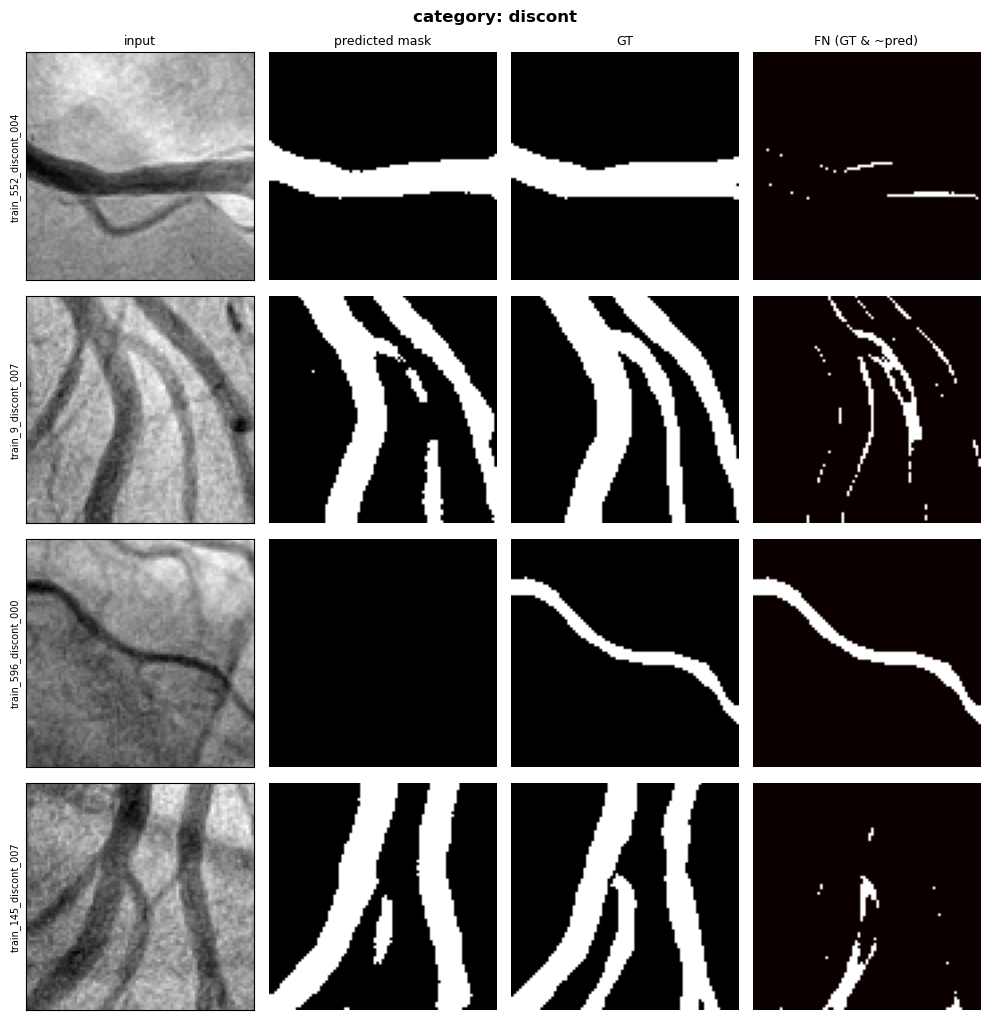

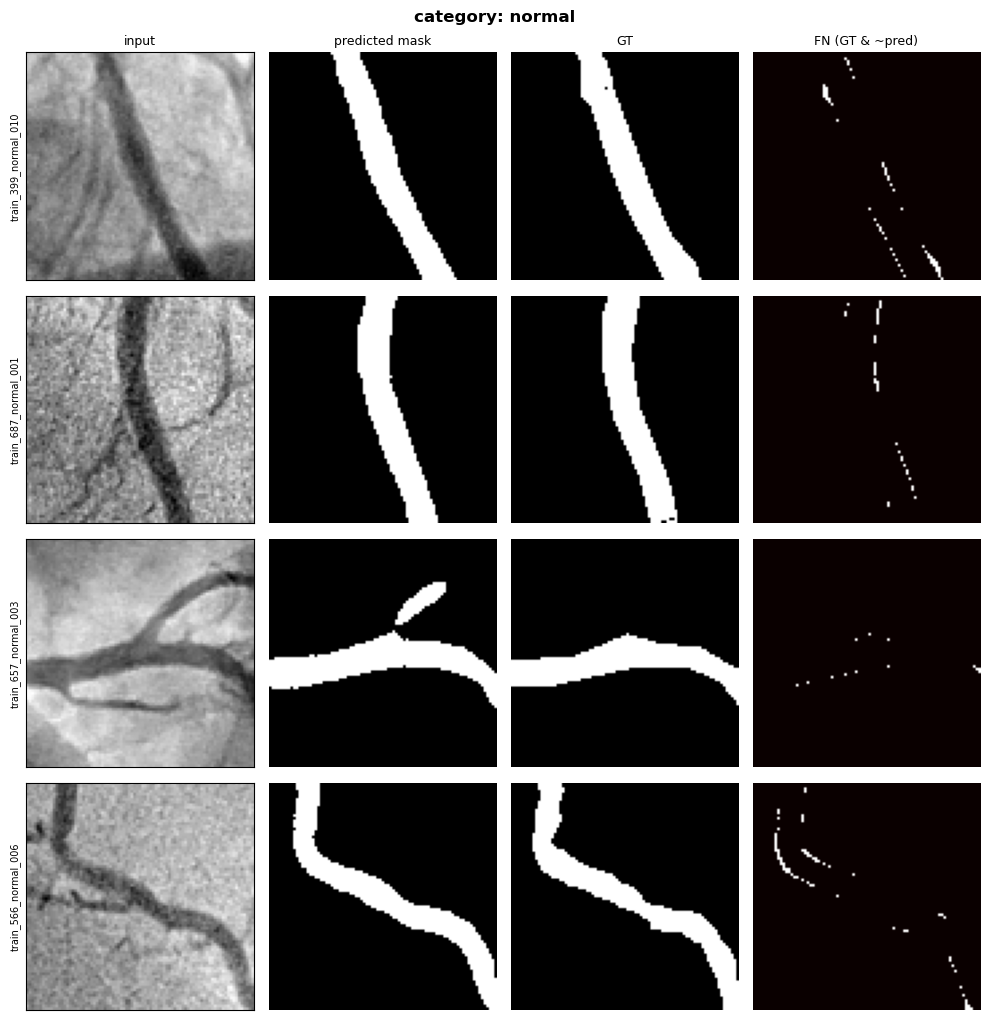

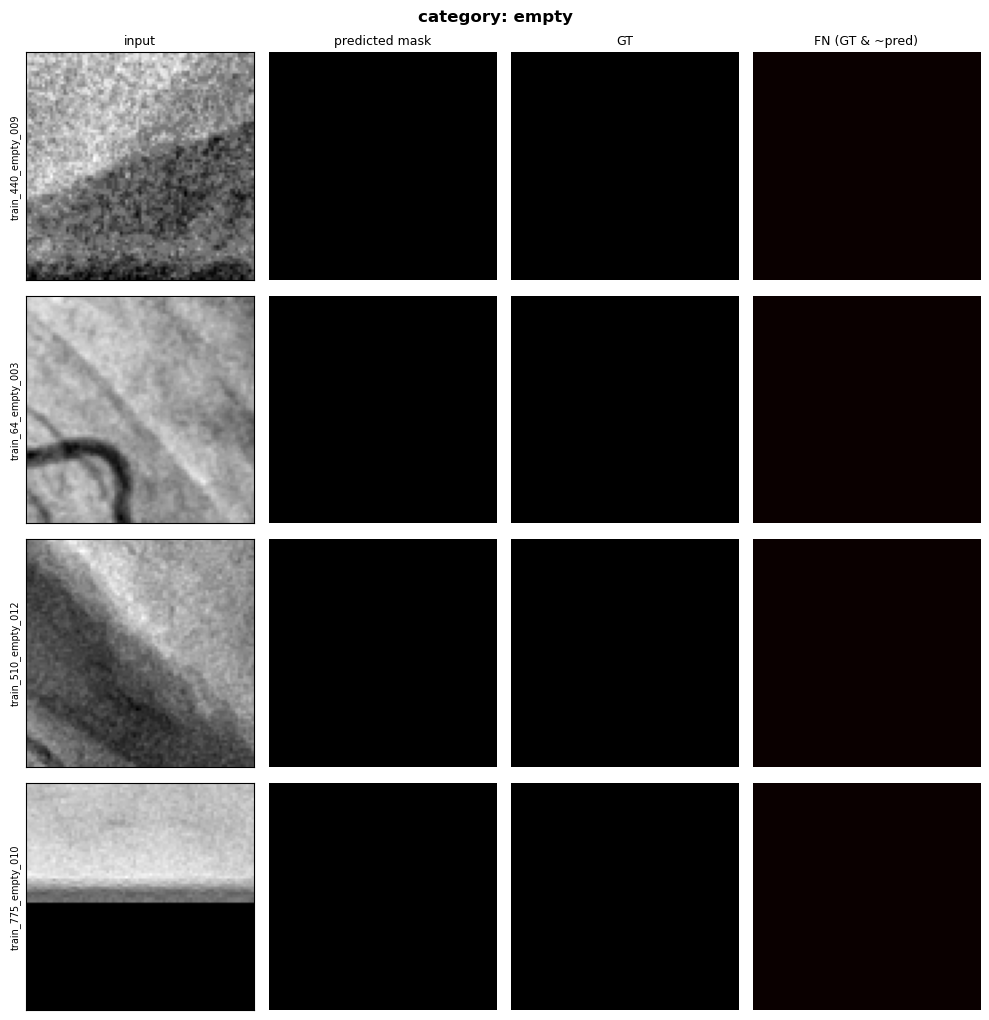

In [3]:
def load_patch(case_id: str, images_dir: Path, labels_dir: Path):
    img = np.asarray(Image.open(images_dir / f"{case_id}_0000.png"))
    pred = np.asarray(Image.open(images_dir / f"{case_id}_0001.png")) > 0
    gt = np.asarray(Image.open(labels_dir / f"{case_id}.png")) > 0
    return img, pred, gt


def show_category_samples(cases: list[str], category: str, n: int = 4):
    matching = [c for c in cases if category_of(c) == category]
    sample = rng.sample(matching, min(n, len(matching)))
    fig, axes = plt.subplots(len(sample), 4, figsize=(10, 2.6 * len(sample)))
    axes = np.atleast_2d(axes)
    for col, title in enumerate(["input", "predicted mask", "GT", "FN (GT & ~pred)"]):
        axes[0, col].set_title(title, fontsize=9)
    for row, case_id in enumerate(sample):
        img, pred, gt = load_patch(case_id, IMAGES_TR, LABELS_TR)
        axes[row, 0].imshow(img, cmap="gray"); axes[row, 0].set_ylabel(case_id, fontsize=7); axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
        axes[row, 1].imshow(pred, cmap="gray"); axes[row, 1].axis("off")
        axes[row, 2].imshow(gt, cmap="gray"); axes[row, 2].axis("off")
        axes[row, 3].imshow(gt & ~pred, cmap="hot"); axes[row, 3].axis("off")
    fig.suptitle(f"category: {category}", fontweight="bold")
    plt.tight_layout()
    plt.show()


for cat in ["discont", "normal", "empty"]:
    show_category_samples(train_cases, cat)

## Sanity checks

Confirms the category logic actually holds across the built dataset, not
just in the samples shown above.

In [4]:
sample_check = rng.sample(train_cases, min(300, len(train_cases)))
rows = []
for case_id in sample_check:
    img, pred, gt = load_patch(case_id, IMAGES_TR, LABELS_TR)
    fn = gt & ~pred
    fp = ~gt & pred
    rows.append({
        "category": category_of(case_id),
        "gt_px": int(gt.sum()), "fn_px": int(fn.sum()), "fp_px": int(fp.sum()),
        "fn_frac": fn.sum() / gt.sum() if gt.any() else np.nan,
    })

import pandas as pd
df = pd.DataFrame(rows)
print("Per-category stats (sample of", len(sample_check), "train cases):")
display(df.groupby("category").agg(["mean", "median", "count"]))

discont_rows = df[df["category"] == "discont"]
normal_rows = df[df["category"] == "normal"]
empty_rows = df[df["category"] == "empty"]
print(f"\ndiscont: {len(discont_rows)} sampled, {(discont_rows['fn_px'] == 0).sum()} with 0 FN (should be ~0)")
print(f"normal: {len(normal_rows)} sampled, {(normal_rows['fn_frac'] > 0.1).sum()} exceeding 10% FN (should be 0)")
print(f"empty: {len(empty_rows)} sampled, {((empty_rows['gt_px'] > 0) & (empty_rows['fp_px'] == 0)).sum()} with vessel but no FP/empty trigger (should be ~0)")

Per-category stats (sample of 300 train cases):


gt_px                     fn_px                    fp_px  \
                 mean  median count        mean median count        mean   
category                                                                   
discont    922.090909   879.5    66  191.287879  116.5    66   71.090909   
empty       17.108108     0.0    74    0.905405    0.0    74    8.148649   
normal    1271.306250  1231.5   160   60.656250   53.5   160  128.456250   

                        fn_frac                  
         median count      mean    median count  
category                                         
discont    67.5    66  0.254360  0.149192    66  
empty       0.0    74  0.052923  0.052923     1  
normal    101.5   160  0.047641  0.044034   160


discont: 66 sampled, 0 with 0 FN (should be ~0)
normal: 160 sampled, 0 exceeding 10% FN (should be 0)
empty: 74 sampled, 0 with vessel but no FP/empty trigger (should be ~0)
